# 📊 Exploración y visualización de escuelas de Pole Dance en España mediante Google Places - (EDA)

---

**Pregunta principal:** ¿Cómo está distribuido el mercado de escuelas de Pole Dance en España y en dónde existen oportunidades para la apertura de nuevos centros?

---

**Secciones:**
   1. Carga y limpieza de datos del dataset
   2. Distribución geográfica
   3. Valoraciones y reputación
   4. Competencia del mercado
   5. Popularidad
   6. Horarios y operación
   7. Presencia digital
   8. Análisis espacial (clusters)
   9. Oportunidades de negocio
   10. Resumen ejecutivo en Consola

---

In [1]:
# =============================================================
# LIBRERÍAS
# =============================================================
import warnings
warnings.filterwarnings("ignore")

import re
import numpy as np
import pandas as pd
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

In [2]:
# =============================================================
# ESTILO GLOBAL DE GRÁFICOS – PALETA ACUÁTICA
# =============================================================
BLUE     = "#0077B6"
TEAL     = "#00B4D8"
LIGHT    = "#90E0EF"
DARK     = "#023047"
GREY     = "#48CAE4"
AQUA_DEEP  = "#0096C7"
AQUA_MID   = "#00BFC4"
AQUA_LIGHT = "#ADE8F4"

PALETTE = [BLUE, TEAL, AQUA_DEEP, AQUA_MID, AQUA_LIGHT,
           "#48CAE4", "#ADE8F4", "#CAF0F8"]

sns.set_theme(style="whitegrid", palette=PALETTE)
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.edgecolor":   GREY,
    "axes.labelcolor":  DARK,
    "text.color":       DARK,
    "xtick.color":      GREY,
    "ytick.color":      GREY,
    "grid.color":       "#EDEDED",
    "font.family":      "DejaVu Sans",
})

In [3]:
# =============================================================
# HELPERS
# =============================================================
def show_fig(fig, *args) -> None:
    plt.show()


def title_bar(ax, title, subtitle=None):
    if subtitle:
        full_title = f"{title}\n\n"
        ax.set_title(full_title, fontsize=24, fontweight="bold", color=DARK, pad=20)
        ax.text(0.5, 1.02, subtitle, transform=ax.transAxes, ha="center", va="bottom", fontsize=9.5, color=GREY, style="italic")
    else:
        ax.set_title(title, fontsize=24, fontweight="bold", color=DARK, pad=12)

def extract_city(address: str) -> str:
    """
    Extrae la ciudad a partir de la dirección formateada de Google Places.
    Estrategia: penúltimo token antes de 'Spain' suele ser ciudad o provincia.
    """
    if pd.isna(address):
        return "Desconocida"
    parts = [p.strip() for p in address.split(",")]
    # Buscar parte que contenga código postal + ciudad
    for p in reversed(parts):
        # Ignorar 'Spain', códigos postales puros, partes muy cortas
        if p in ("Spain", "España"):
            continue
        # Quitar código postal del inicio si lo hay
        city = re.sub(r"^\d{5}\s*", "", p).strip()
        if len(city) > 2:
            return city
    return "Desconocida"


def parse_horario(horario_str: str) -> dict:
    """
    Parsea la cadena de horario y devuelve un dict {dia: horario_str}.
    Ejemplo de entrada: 'lunes: 10:00–22:00 | martes: 11:00–22:00 | ...'
    """
    result = {}
    if pd.isna(horario_str):
        return result
    days_raw = horario_str.split("|")
    for day_raw in days_raw:
        day_raw = day_raw.strip()
        if ":" not in day_raw:
            continue
        day, hours = day_raw.split(":", 1)
        result[day.strip().lower()] = hours.strip()
    return result


def extract_closing_hour(hours_str: str) -> float | None:
    """
    Extrae la hora de cierre (float) de un string como '10:00–22:00'
    o '10:00–13:00, 17:00–22:00' (toma el último cierre del día).
    """
    if not hours_str or hours_str.lower() in ("cerrado", "24 horas"):
        return None
    # Buscar todos los patrones HH:MM después de '–'
    matches = re.findall(r"–\s*(\d{1,2}):(\d{2})", hours_str)
    if not matches:
        return None
    h, m = matches[-1]
    return int(h) + int(m) / 60

In [4]:
# =============================================================
# 1. CARGA Y LIMPIEZA DE DATOS DEL DATASET
# =============================================================
print("\n" + "="*60)
print(" 1. CARGA Y LIMPIEZA DE DATOS DEL DATASET")
print("="*60)

# Carga del dataset
df_raw = pd.read_csv("dataset/pole_dance_spain_enriched.csv")
print(f"Filas originales : {len(df_raw):,}")

# Visualizar las primeras 5 filas del dataset
df_raw.head()

# Ver cuántas filas y columnas tiene el dataset antes de limpiar
df_raw.shape
print(f"Filas: {df_raw.shape[0]}, Columnas: {df_raw.shape[1]}")

# Eliminar duplicados por place_id
df = df_raw.drop_duplicates(subset="place_id").copy()
print(f"Sin place_id duplicados: {len(df):,}")

# Filtrar solo negocios operativos
df = df[df["business_status"].isin(["OPERATIONAL", None, np.nan]) |
        df["business_status"].isna()].copy()

# Eliminar negocios cerrados permanentemente
df = df[df["business_status"] != "CLOSED_PERMANENTLY"].copy()
print(f"Negocios Operativos: {len(df):,}")

# Transformación de nombres a minúsculas para realizar búsqueda insensible a letras mayúsculas
df["name_clean"] = df["name"].str.lower().fillna("")

#Filtrado de negocios que si bien pueden estar relacionados con el pole dance no funcionan como una escuela/academia de pole dance
black_list = ["decathlon", "sprinter", "shop", "store", "boutique", "juguetes", "sex", "erotic", "tienda", 
              "coffee", "digital", "arte", "sparta", "gym", "gimnasio", "beone","victoria club", "bombas gens", 
              "go fit", "viding", "sports leisure", "leisure center", "torreones", "padel", "club de campo"
              "museum", "danza", "spa", "88", "abfitness", "sports center", "calistenia", "english academy"]
black_list_filter = df["name_clean"].apply(lambda x: not any(word in x for word in black_list))
df = df[black_list_filter].copy()

#Filtrado de negocios que es más probable que funcionen como una escuela/academia de pole dance
white_list = ["pole", "studio", "estudio", "escuela", "academy", "academia", "fitness", "loft", "club", "center", 
              "centro", "aerial", "exotic", "heels", "telas", "aerial", "aéreos", "aéreo"]
white_list_filter = df["name_clean"].apply(lambda x: any(word in x for word in white_list))
df = df[white_list_filter].copy()

# Eliminar columna temporal de limpieza para dejar el dataset limpio
df.drop(columns=["name_clean"], inplace=True)

# Extraer ciudad
df["city"] = df["formatted_address"].apply(extract_city)

# Province ya viene en 'province_search'
df.rename(columns={"province_search": "province"}, inplace=True)

# Comunidad Autónoma mapping (simplificado por provincias)
CA_MAP = {
    "Madrid": "Madrid", "Barcelona": "Cataluña", "Girona": "Cataluña",
    "Lleida": "Cataluña", "Tarragona": "Cataluña",
    "Valencia": "C. Valenciana", "Alicante": "C. Valenciana",
    "Castellón": "C. Valenciana", "Sevilla": "Andalucía",
    "Málaga": "Andalucía", "Córdoba": "Andalucía", "Granada": "Andalucía",
    "Almería": "Andalucía", "Cádiz": "Andalucía", "Huelva": "Andalucía",
    "Jaén": "Andalucía", "Bilbao": "País Vasco", "San Sebastián": "País Vasco",
    "Álava": "País Vasco", "Vizcaya": "País Vasco", "Guipúzcoa": "País Vasco",
    "Zaragoza": "Aragón", "Huesca": "Aragón", "Teruel": "Aragón",
    "Navarra": "Navarra", "La Rioja": "La Rioja", "Murcia": "Murcia",
    "Palma de Mallorca": "Islas Baleares", "Islas Baleares": "Islas Baleares",
    "Las Palmas": "Canarias", "Santa Cruz de Tenerife": "Canarias",
    "Canarias": "Canarias", "A Coruña": "Galicia", "Pontevedra": "Galicia",
    "Lugo": "Galicia", "Ourense": "Galicia",
    "Asturias": "Asturias", "Cantabria": "Cantabria",
    "Valladolid": "Castilla y León", "León": "Castilla y León",
    "Burgos": "Castilla y León", "Salamanca": "Castilla y León",
    "Ávila": "Castilla y León", "Palencia": "Castilla y León",
    "Zamora": "Castilla y León", "Segovia": "Castilla y León",
    "Soria": "Castilla y León",
    "Toledo": "Castilla-La Mancha", "Albacete": "Castilla-La Mancha",
    "Ciudad Real": "Castilla-La Mancha", "Cuenca": "Castilla-La Mancha",
    "Guadalajara": "Castilla-La Mancha",
    "Badajoz": "Extremadura", "Cáceres": "Extremadura",
    "Ceuta": "Ceuta", "Melilla": "Melilla",
}
df["ccaa"] = df["province"].map(CA_MAP).fillna("Otras")

# Variables numéricas
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
df["user_ratings_total"] = pd.to_numeric(df["user_ratings_total"], errors="coerce")

# Presencia digital
df["has_website"] = df["website"].notna() & (df["website"] != "")
df["has_phone"]   = df["phone"].notna()   & (df["phone"]   != "")
df["has_horario"] = df["horario"].notna()

# Horario parseado
df["horario_dict"] = df["horario"].apply(parse_horario)

print(f"Columnas finales: {list(df.columns)}")
print(f"Provincias únicas: {df['province'].nunique()}")
print(f"Rating medio: {df['rating'].mean():.3f}")
print(f"Total escuelas: {len(df):,}")

# Datos de población por provincia (INE 2023, miles de hab.)
# Fuente: INE Padrón Municipal 2023
POBLACION_PROVINCIA = {
    "Madrid": 6_751_251, "Barcelona": 5_630_467, "Valencia": 2_575_362,
    "Sevilla": 1_937_919, "Alicante": 1_875_523, "Málaga": 1_695_651,
    "Murcia": 1_513_530, "Cádiz": 1_236_739, "Vizcaya": 1_149_558,
    "La Coruña": 1_120_282, "A Coruña": 1_120_282,
    "Tenerife": 1_040_506, "Santa Cruz de Tenerife": 1_040_506,
    "Zaragoza": 979_867, "Las Palmas": 1_107_220, "Granada": 916_913,
    "Asturias": 1_010_337, "Córdoba": 772_015, "Valladolid": 518_576,
    "Pontevedra": 945_852, "Almería": 730_829, "Bilbao": 1_149_558,
    "Guipúzcoa": 724_158, "San Sebastián": 724_158,
    "Tarragona": 836_528, "Navarra": 661_537,
    "Girona": 784_672, "Lleida": 453_530,
    "Badajoz": 682_518, "Huelva": 527_924, "León": 451_004,
    "Burgos": 352_869, "Jaén": 613_404, "Toledo": 714_341,
    "Salamanca": 322_869, "Albacete": 399_253, "Cáceres": 387_411,
    "Castellón": 611_371, "La Rioja": 325_701, "Cantabria": 584_507,
    "Lugo": 325_671, "Ourense": 306_948, "Ávila": 161_702,
    "Palencia": 159_017, "Cuenca": 200_226, "Guadalajara": 276_762,
    "Segovia": 157_538, "Soria": 90_040, "Zamora": 170_024,
    "Teruel": 140_767, "Ciudad Real": 497_371,
    "Ceuta": 82_376, "Melilla": 85_584,
    "Islas Baleares": 1_173_008, "Palma de Mallorca": 1_173_008,
    "Álava": 335_219,
}

# Visualizar las primeras 5 filas del dataset tras la limpieza de datos
df.head()

# Ver cuántas filas y columnas tiene el dataset después de limpiar
df.shape
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")


 1. CARGA Y LIMPIEZA DE DATOS DEL DATASET
Filas originales : 3,626
Filas: 3626, Columnas: 18
Sin place_id duplicados: 699
Negocios Operativos: 696
Columnas finales: ['search_query', 'province', 'timestamp', 'place_id', 'name', 'formatted_address', 'rating', 'user_ratings_total', 'lat', 'lng', 'business_status', 'types', 'website', 'phone', 'horario', 'google_maps_url', 'lat_precisa', 'lng_precisa', 'city', 'ccaa', 'has_website', 'has_phone', 'has_horario', 'horario_dict']
Provincias únicas: 47
Rating medio: 4.836
Total escuelas: 319
Filas: 319, Columnas: 24



 2. DISTRIBUCIÓN GEOGRÁFICA


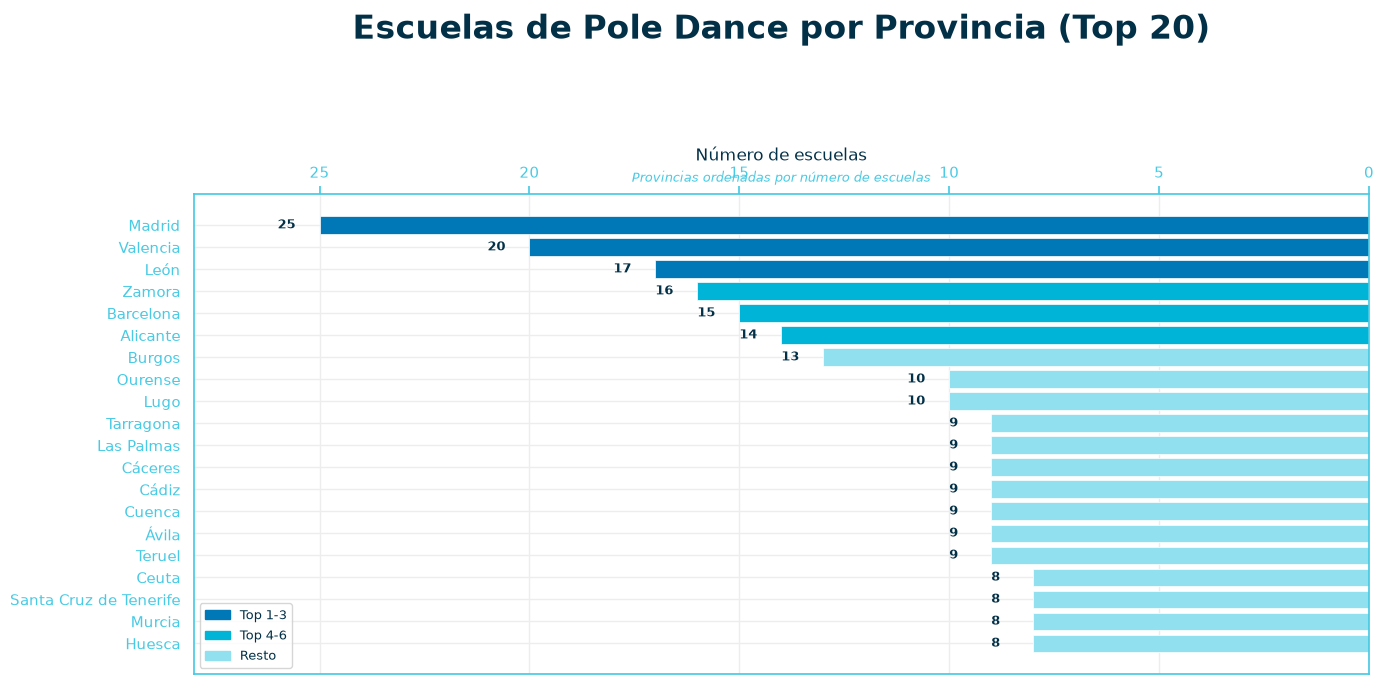

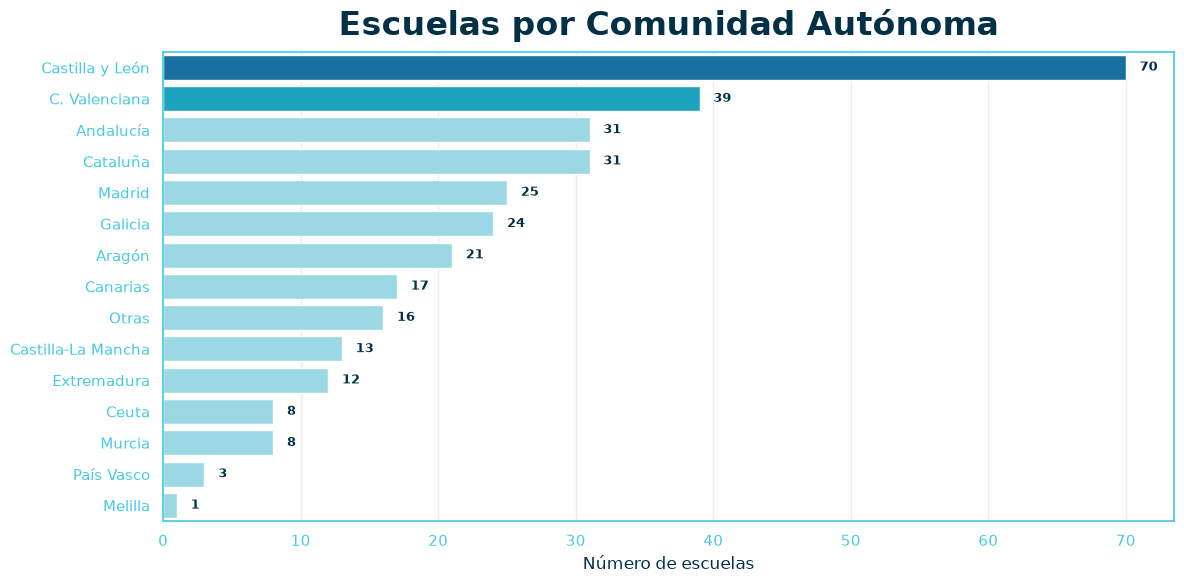

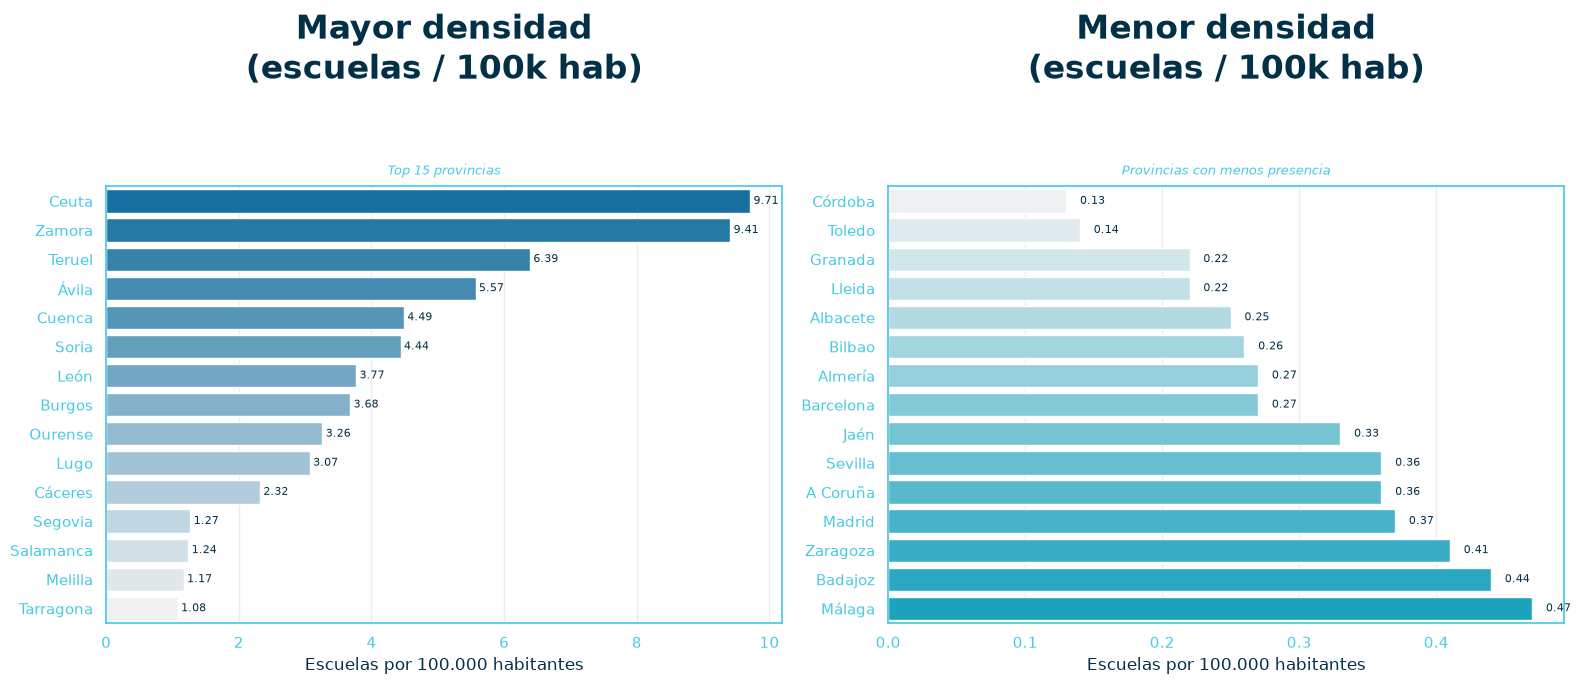

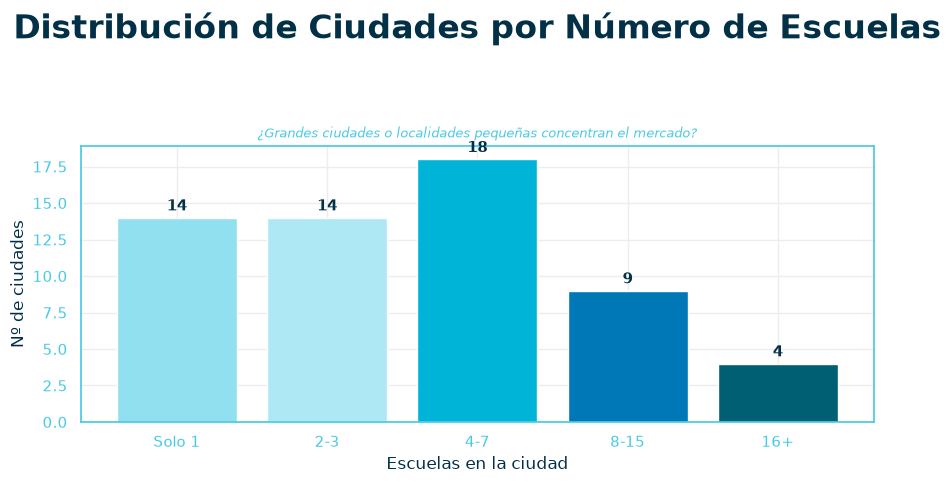

In [5]:
# =============================================================
# 2. DISTRIBUCIÓN GEOGRÁFICA
# =============================================================
print("\n" + "="*60)
print(" 2. DISTRIBUCIÓN GEOGRÁFICA")
print("="*60)

# ── 2.1  Escuelas por provincia (Top 20) ──────────────────
schools_prov = (df.groupby("province")
                  .size()
                  .reset_index(name="n_schools")
                  .sort_values("n_schools", ascending=False))

fig, ax = plt.subplots(figsize=(14, 7))
top20 = schools_prov.head(20)
colors = [BLUE if i < 3 else (TEAL if i < 6 else LIGHT)
          for i in range(len(top20))]
bars = ax.barh(top20["province"][::-1], top20["n_schools"][::-1],
               color=colors[::-1], edgecolor="white", linewidth=0.5)
for bar, val in zip(bars, top20["n_schools"][::-1]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            str(val), va="center", fontsize=9, color=DARK, fontweight="bold")
title_bar(ax, "Escuelas de Pole Dance por Provincia (Top 20)",
          "Provincias ordenadas por número de escuelas")
ax.set_xlabel("Número de escuelas")
ax.set_xlim(0, top20["n_schools"].max() * 1.12)
ax.invert_xaxis()
ax.xaxis.set_label_position("top")
ax.xaxis.tick_top()
patches = [mpatches.Patch(color=BLUE, label="Top 1-3"),
           mpatches.Patch(color=TEAL, label="Top 4-6"),
           mpatches.Patch(color=LIGHT, label="Resto")]
ax.legend(handles=patches, loc="lower left", fontsize=9)
plt.tight_layout()
show_fig(fig, "01_escuelas_por_provincia")

# ── 2.2  Escuelas por Comunidad Autónoma ─────────────────
schools_ca = (df.groupby("ccaa")
                .size()
                .reset_index(name="n_schools")
                .sort_values("n_schools", ascending=False))

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=schools_ca, y="ccaa", x="n_schools", ax=ax,
            palette=sns.color_palette([BLUE, TEAL] +
                                      [LIGHT]*len(schools_ca), n_colors=len(schools_ca)))
for i, row in enumerate(schools_ca.itertuples()):
    ax.text(row.n_schools + 1, i, str(row.n_schools),
            va="center", fontsize=9, fontweight="bold", color=DARK)
title_bar(ax, "Escuelas por Comunidad Autónoma")
ax.set_xlabel("Número de escuelas")
ax.set_ylabel("")
plt.tight_layout()
show_fig(fig, "02_escuelas_por_ccaa")

# ── 2.3  Densidad escuelas / 100k hab ────────────────────
schools_prov["poblacion"] = schools_prov["province"].map(POBLACION_PROVINCIA)
schools_prov["densidad_100k"] = (
    schools_prov["n_schools"] / schools_prov["poblacion"] * 100_000
).round(2)
top_densidad = schools_prov.dropna(subset=["densidad_100k"]).sort_values(
    "densidad_100k", ascending=False).head(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
# Izquierda: mayor densidad
ax = axes[0]
sns.barplot(data=top_densidad.head(15), y="province", x="densidad_100k",
            ax=ax, palette=sns.light_palette(BLUE, n_colors=15, reverse=True))
for i, row in enumerate(top_densidad.head(15).itertuples()):
    ax.text(row.densidad_100k + 0.05, i, f"{row.densidad_100k:.2f}",
            va="center", fontsize=8, color=DARK)
title_bar(ax, "Mayor densidad\n(escuelas / 100k hab)", "Top 15 provincias")
ax.set_xlabel("Escuelas por 100.000 habitantes")
ax.set_ylabel("")

# Derecha: menor densidad (provincias con presencia reducida)
bottom_densidad = schools_prov.dropna(subset=["densidad_100k"]).sort_values(
    "densidad_100k").head(15)
ax2 = axes[1]
sns.barplot(data=bottom_densidad, y="province", x="densidad_100k",
            ax=ax2, palette=sns.light_palette(TEAL, n_colors=15, reverse=False))
for i, row in enumerate(bottom_densidad.itertuples()):
    ax2.text(row.densidad_100k + 0.01, i, f"{row.densidad_100k:.2f}",
             va="center", fontsize=8, color=DARK)
title_bar(ax2, "Menor densidad\n(escuelas / 100k hab)", "Provincias con menos presencia")
ax2.set_xlabel("Escuelas por 100.000 habitantes")
ax2.set_ylabel("")
plt.tight_layout()
show_fig(fig, "03_densidad_por_provincia")

# ── 2.4  Grandes ciudades vs localidades pequeñas ────────
city_counts = df.groupby("city").size().reset_index(name="n_schools")
city_counts["categoria"] = pd.cut(
    city_counts["n_schools"],
    bins=[0, 1, 3, 7, 15, city_counts["n_schools"].max()],
    labels=["Solo 1", "2-3", "4-7", "8-15", "16+"]
)
cat_dist = city_counts["categoria"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(cat_dist.index, cat_dist.values,
              color=[LIGHT, "#ADE8F4", TEAL, BLUE, "#005F73"],
              edgecolor="white", linewidth=1)
for bar, val in zip(bars, cat_dist.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(val), ha="center", fontsize=11, fontweight="bold", color=DARK)
title_bar(ax, "Distribución de Ciudades por Número de Escuelas",
          "¿Grandes ciudades o localidades pequeñas concentran el mercado?")
ax.set_xlabel("Escuelas en la ciudad")
ax.set_ylabel("Nº de ciudades")
plt.tight_layout()
show_fig(fig, "04_escuelas_por_tamanyo_ciudad")

---

*Las escuelas de Pole Dance en España se concentran de forma desigual.*

*Madrid y Barcelona lideran en número absoluto de escuelas, seguidas por Valencia y otras grandes ciudades costeras. Sin embargo, cuando se ajusta por población (densidad por 100k hab.), ciudades como Valencia, Las Palmas y Santa Cruz de Tenerife muestran una mayor penetración relativa del mercado.*

*La mayoría de ciudades tienen entre 1 y 3 escuelas, lo que indica un mercado fragmentado donde predominan las localidades pequeñas con presencia reducida.* 

*Existe una oportunidad clara en provincias de alta población pero baja densidad de escuelas.*

---


 3. VALORACIONES Y REPUTACIÓN


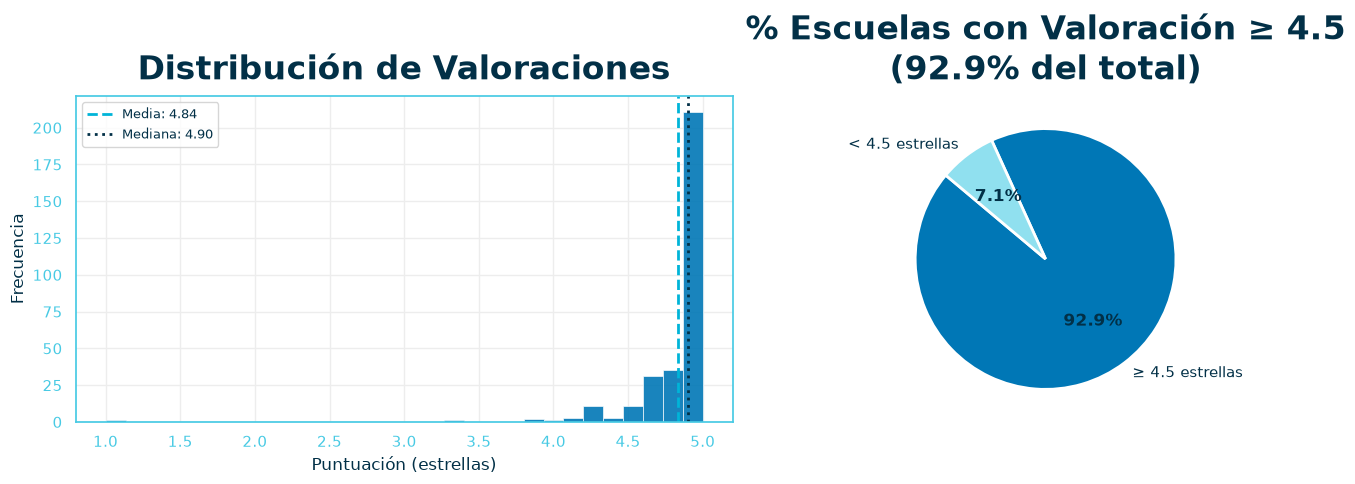

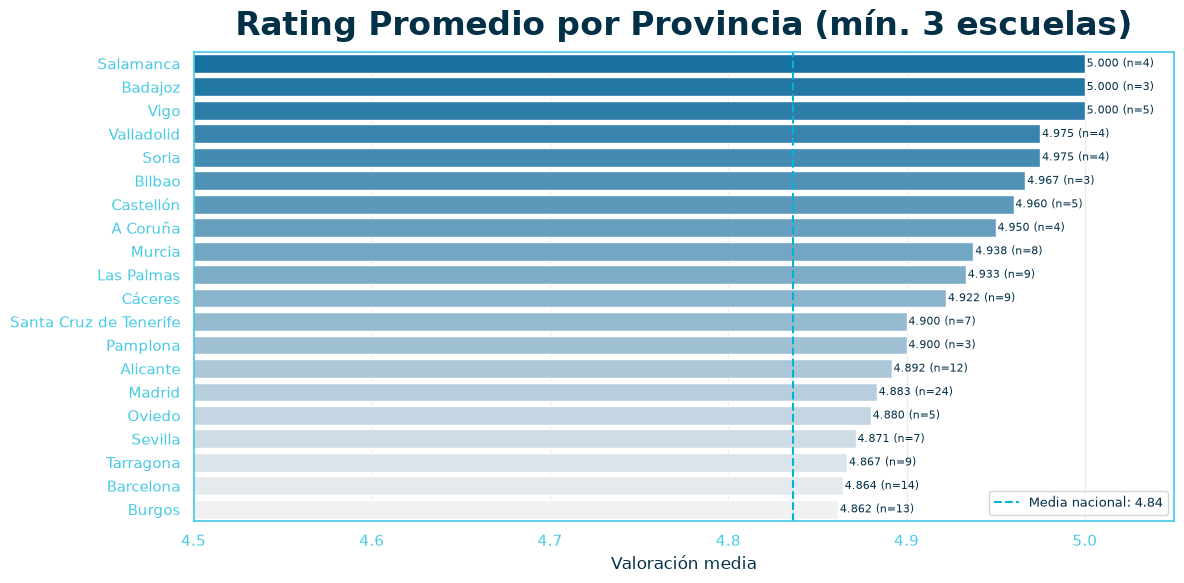

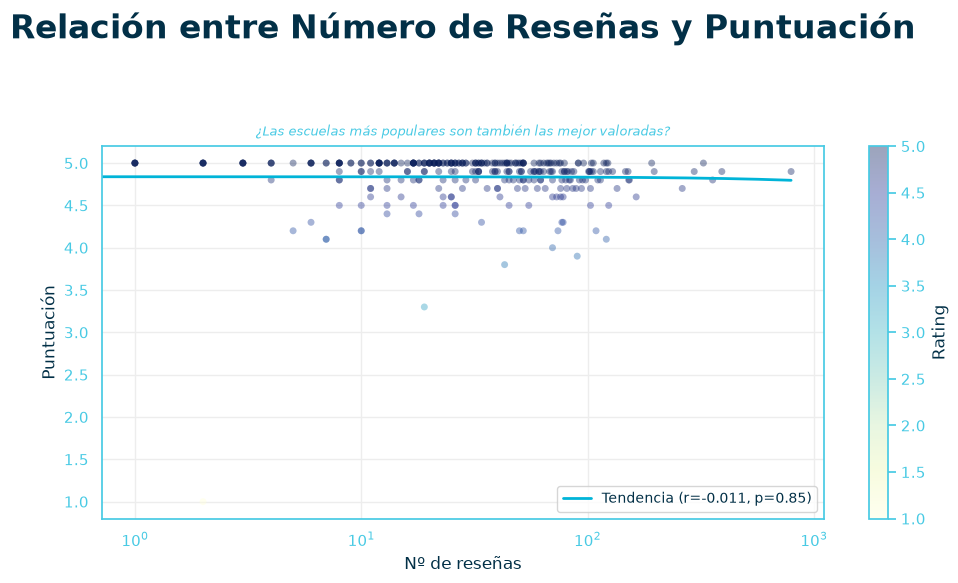

In [6]:
# =============================================================
# 3. VALORACIONES Y REPUTACIÓN
# =============================================================
print("\n" + "="*60)
print(" 3. VALORACIONES Y REPUTACIÓN")
print("="*60)

df_rated = df.dropna(subset=["rating"]).copy()

# ── 3.1  Distribución de ratings ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
ax.hist(df_rated["rating"], bins=30, color=BLUE, edgecolor="white",
        linewidth=0.5, alpha=0.9)
ax.axvline(df_rated["rating"].mean(), color=TEAL, linestyle="--",
           linewidth=2, label=f"Media: {df_rated['rating'].mean():.2f}")
ax.axvline(df_rated["rating"].median(), color=DARK, linestyle=":",
           linewidth=2, label=f"Mediana: {df_rated['rating'].median():.2f}")
ax.legend(fontsize=9)
title_bar(ax, "Distribución de Valoraciones")
ax.set_xlabel("Puntuación (estrellas)")
ax.set_ylabel("Frecuencia")

# Porcentaje con valoración > 4.5
pct_45 = (df_rated["rating"] >= 4.5).mean() * 100
ax2 = axes[1]
labels = ["≥ 4.5 estrellas", "< 4.5 estrellas"]
sizes  = [pct_45, 100 - pct_45]
wedges, texts, autotexts = ax2.pie(
    sizes, labels=labels, autopct="%1.1f%%",
    colors=[BLUE, LIGHT], startangle=140,
    wedgeprops=dict(edgecolor="white", linewidth=2))
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight("bold")
title_bar(ax2, f"% Escuelas con Valoración ≥ 4.5\n({pct_45:.1f}% del total)")
plt.tight_layout()
show_fig(fig, "05_distribucion_valoraciones")

# ── 3.2  Rating promedio por provincia (Top 20 con ≥3 escuelas) ──
prov_rating = (df_rated.groupby("province")
               .agg(avg_rating=("rating", "mean"),
                    n=("rating", "count"))
               .reset_index()
               .query("n >= 3")
               .sort_values("avg_rating", ascending=False)
               .head(20))

fig, ax = plt.subplots(figsize=(12, 6))
palette_rating = sns.light_palette(BLUE, n_colors=len(prov_rating), reverse=True)
sns.barplot(data=prov_rating, y="province", x="avg_rating", ax=ax,
            palette=palette_rating)
ax.axvline(df_rated["rating"].mean(), color=TEAL, linestyle="--",
           linewidth=1.5, label=f"Media nacional: {df_rated['rating'].mean():.2f}")
for i, row in enumerate(prov_rating.itertuples()):
    ax.text(row.avg_rating + 0.001, i, f"{row.avg_rating:.3f} (n={row.n})",
            va="center", fontsize=8, color=DARK)
ax.legend(fontsize=9)
title_bar(ax, "Rating Promedio por Provincia (mín. 3 escuelas)")
ax.set_xlabel("Valoración media")
ax.set_ylabel("")
ax.set_xlim(4.5, 5.05)
plt.tight_layout()
show_fig(fig, "06_rating_por_provincia")

# ── 3.3  Relación rating vs nº reseñas ───────────────────
df_scatter = df_rated.dropna(subset=["user_ratings_total"]).copy()

fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(df_scatter["user_ratings_total"], df_scatter["rating"],
                alpha=0.4, c=df_scatter["rating"], cmap="YlGnBu",
                edgecolors="none", s=25)
# Línea de tendencia
m, b, r, p, _ = stats.linregress(df_scatter["user_ratings_total"],
                                  df_scatter["rating"])
x_line = np.linspace(0, df_scatter["user_ratings_total"].max(), 200)
ax.plot(x_line, m * x_line + b, color=TEAL, linewidth=2,
        label=f"Tendencia (r={r:.3f}, p={'<0.05' if p < 0.05 else f'{p:.2f}'})")
plt.colorbar(sc, ax=ax, label="Rating")
ax.legend(fontsize=10)
title_bar(ax, "Relación entre Número de Reseñas y Puntuación",
          "¿Las escuelas más populares son también las mejor valoradas?")
ax.set_xlabel("Nº de reseñas")
ax.set_ylabel("Puntuación")
ax.set_xscale("log")
plt.tight_layout()
show_fig(fig, "07_rating_vs_resenas")

---

*La valoración media de las escuelas de Pole Dance en España es extremadamente alta (≈4.84 sobre 5), con más del 90% de escuelas superando las 4.5 estrellas.*

*Esto refleja un sector con un nivel de satisfacción del cliente muy elevado.*

*Las escuelas más populares (con más reseñas) tienden a mantener valoraciones altas.*

*La correlación no es perfecta ya que algunas escuelas con pocas reseñas también alcanzan puntuaciones de 5.0, mientras que escuelas muy populares pueden tener ratings ligeramente menores (4.6-4.7), posiblemente por mayor exposición y diversidad de opiniones. No obstante, la tendencia general es positiva: a mayor número de interacciones, la valoración se mantiene en niveles altos.*

---


 4. COMPETENCIA DEL MERCADO


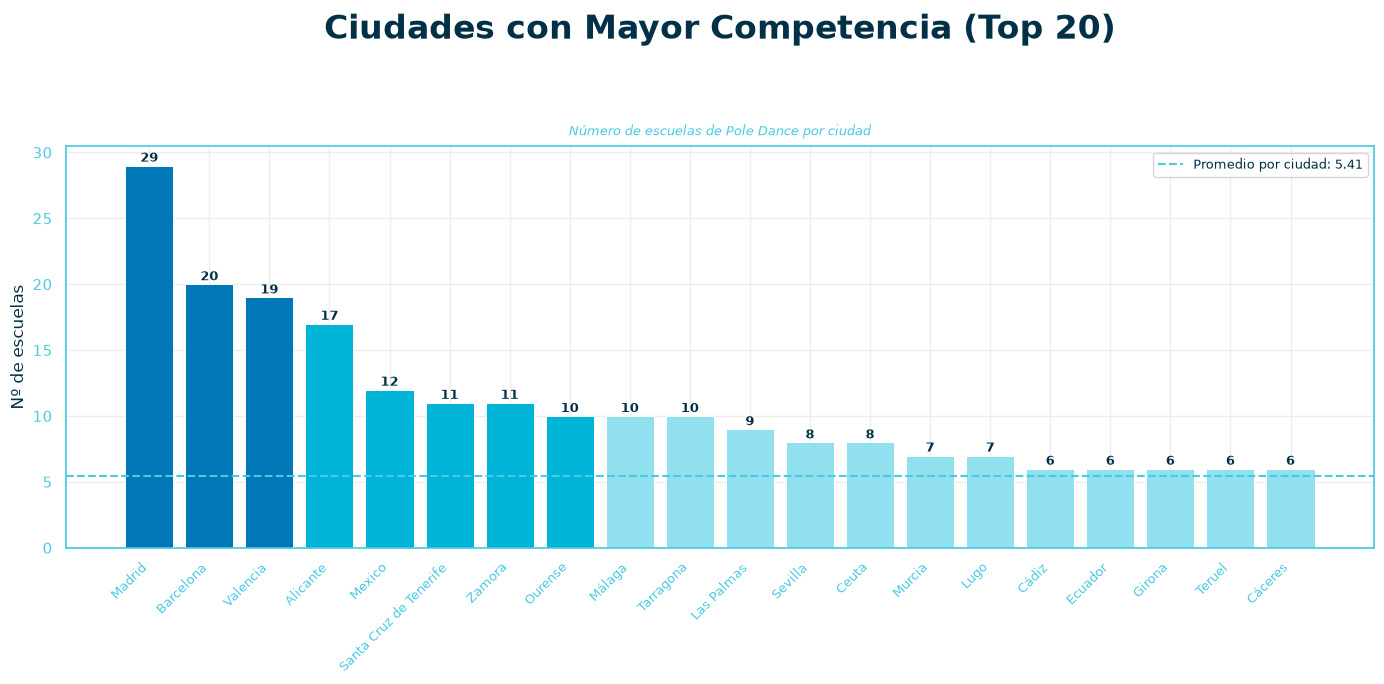

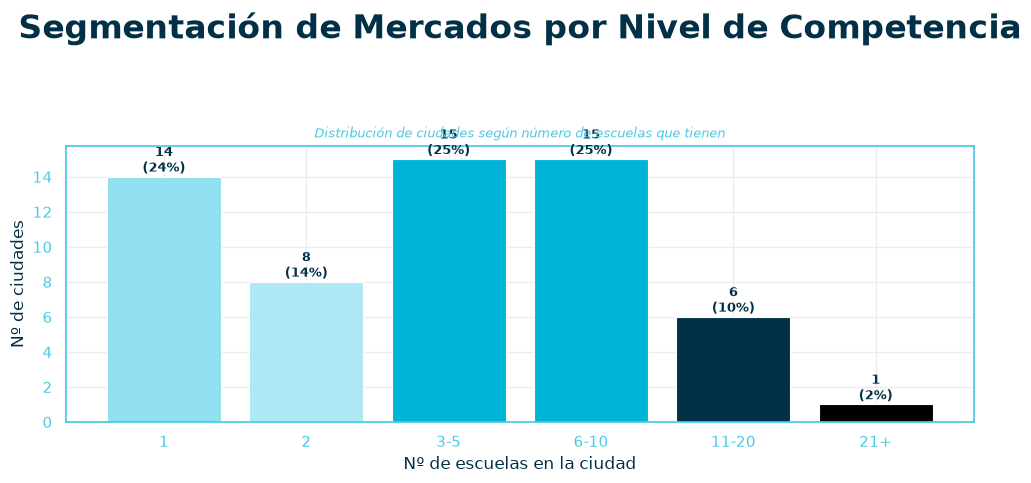

In [7]:
# =============================================================
# 4. COMPETENCIA DEL MERCADO
# =============================================================
print("\n" + "="*60)
print(" 4. COMPETENCIA DEL MERCADO")
print("="*60)

# ── 4.1  Escuelas por ciudad (Top 20) ─────────────────────
top_cities = city_counts.sort_values("n_schools", ascending=False).head(20)

fig, ax = plt.subplots(figsize=(14, 7))
colors_city = [BLUE if i < 3 else (TEAL if i < 8 else LIGHT)
               for i in range(len(top_cities))]
bars = ax.bar(range(len(top_cities)), top_cities["n_schools"],
              color=colors_city, edgecolor="white", linewidth=0.7)
ax.set_xticks(range(len(top_cities)))
ax.set_xticklabels(top_cities["city"], rotation=45, ha="right", fontsize=9)
for bar, val in zip(bars, top_cities["n_schools"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(val), ha="center", fontsize=9, fontweight="bold", color=DARK)
avg_per_city = city_counts["n_schools"].mean()
ax.axhline(avg_per_city, color=GREY, linestyle="--", linewidth=1.5,
           label=f"Promedio por ciudad: {avg_per_city:.2f}")
ax.legend(fontsize=9)
title_bar(ax, "Ciudades con Mayor Competencia (Top 20)",
          "Número de escuelas de Pole Dance por ciudad")
ax.set_ylabel("Nº de escuelas")
plt.tight_layout()
show_fig(fig, "08_competencia_por_ciudad")

# ── 4.2  Saturación: distribución de mercados ─────────────
fig, ax = plt.subplots(figsize=(10, 5))
bins = [0, 1, 2, 5, 10, 20, city_counts["n_schools"].max() + 1]
labels_bins = ["1", "2", "3-5", "6-10", "11-20", f"21+"]
city_counts["segmento"] = pd.cut(city_counts["n_schools"],
                                  bins=bins, labels=labels_bins, right=True)
seg_counts = city_counts["segmento"].value_counts().sort_index()
bars = ax.bar(seg_counts.index, seg_counts.values,
              color=sns.color_palette([LIGHT, "#ADE8F4", "#00B4D8",
                                       TEAL, DARK, "#000000"],
                                       n_colors=len(seg_counts)),
              edgecolor="white", linewidth=0.8)
for bar, val in zip(bars, seg_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{val}\n({val/len(city_counts)*100:.0f}%)",
            ha="center", fontsize=9, fontweight="bold", color=DARK)
title_bar(ax, "Segmentación de Mercados por Nivel de Competencia",
          "Distribución de ciudades según número de escuelas que tienen")
ax.set_xlabel("Nº de escuelas en la ciudad")
ax.set_ylabel("Nº de ciudades")
plt.tight_layout()
show_fig(fig, "09_saturacion_mercados")

---

*El análisis de competencia revela que la mayoría de ciudades españolas tienen entre 1 y 3 escuelas de Pole Dance, lo que indica un mercado poco saturado a nivel local.*

*Solo unas pocas ciudades (Madrid, Barcelona, Valencia, Sevilla) concentran una competencia significativa.*

*La distribución muestra una estructura de cola larga: muchas localidades con presencia mínima y muy pocas con alta concentración. Esto sugiere que el mercado está lejos de estar saturado en la mayoría del territorio nacional, y que existe espacio para nuevos centros tanto en ciudades medianas como en barrios específicos de grandes urbes donde la cobertura puede ser insuficiente.*

---


 5. POPULARIDAD


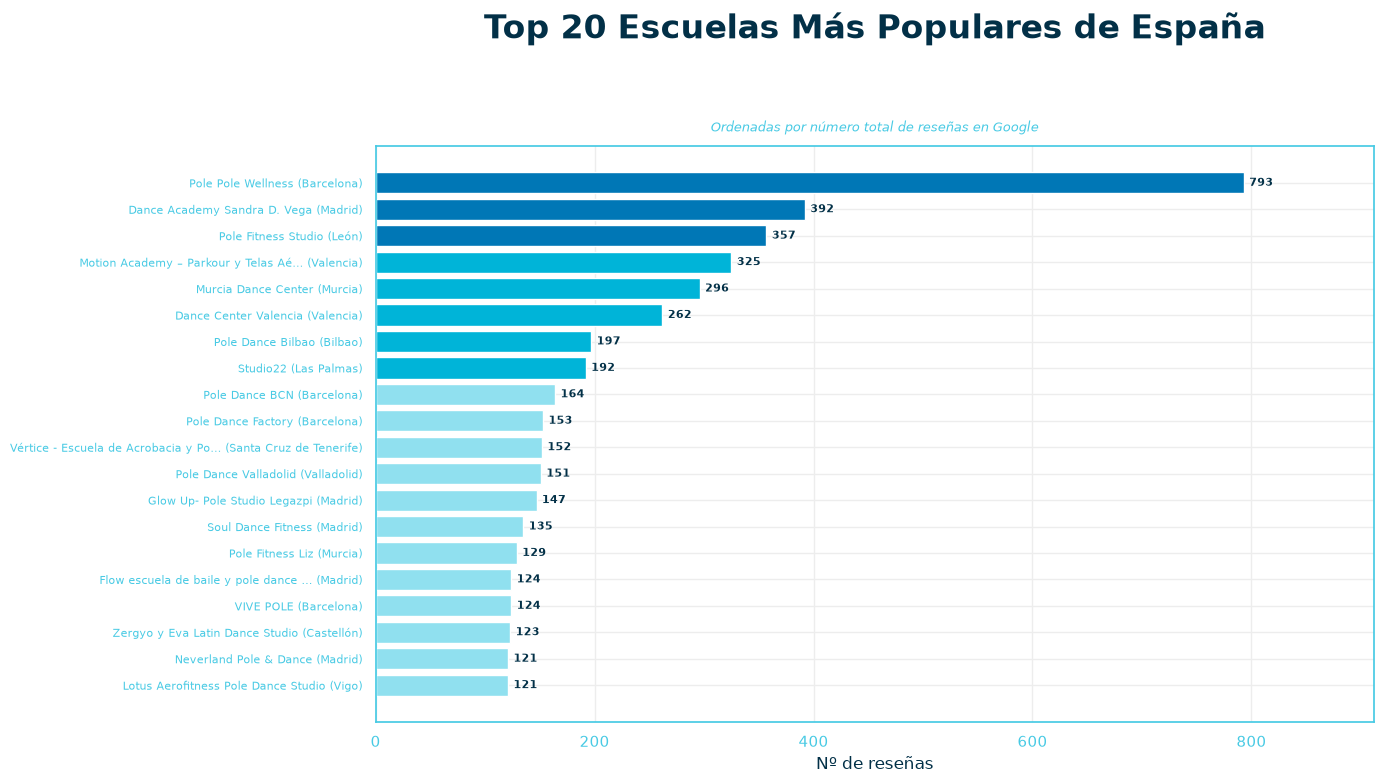


  TOP 20 ESCUELAS MÁS POPULARES:
                                               name               province                   city  rating  user_ratings_total
                                 Pole Pole Wellness              Barcelona              Barcelona     4.9               793.0
                       Dance Academy Sandra D. Vega                 Madrid                 Madrid     4.9               392.0
                                Pole Fitness Studio                   León                    USA     4.8               357.0
Motion Academy – Parkour y Telas Aéreas en Valencia               Valencia               Valencia     5.0               325.0
                                Murcia Dance Center                 Murcia                 Murcia     4.9               296.0
                              Dance Center Valencia               Valencia               Valencia     4.7               262.0
                                  Pole Dance Bilbao                 Bilbao          

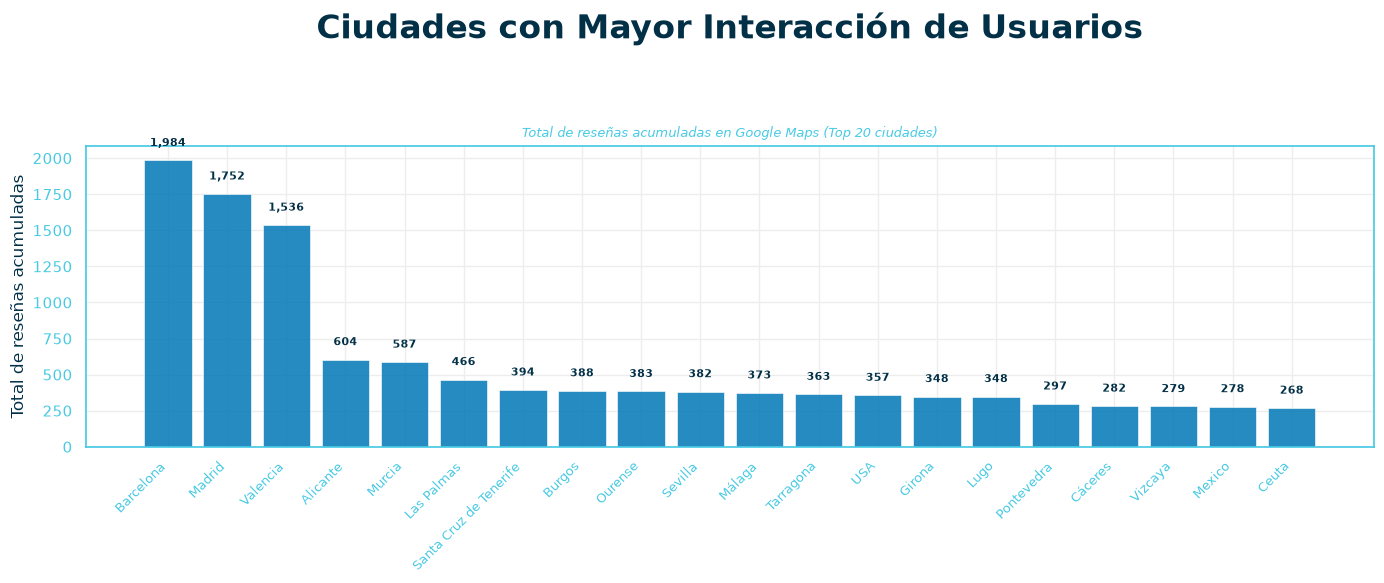

In [8]:
# =============================================================
# 5. POPULARIDAD
# =============================================================
print("\n" + "="*60)
print(" 5. POPULARIDAD")
print("="*60)

df_pop = df.dropna(subset=["user_ratings_total"]).copy()

# ── 5.1  Top 20 escuelas por reseñas ─────────────────────
top20_schools = df_pop.nlargest(20, "user_ratings_total")[
    ["name", "province", "city", "rating", "user_ratings_total"]
].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 8))
colors_s = [BLUE if i < 3 else (TEAL if i < 8 else LIGHT)
            for i in range(len(top20_schools))]
bars = ax.barh(range(len(top20_schools)),
               top20_schools["user_ratings_total"][::-1],
               color=colors_s[::-1], edgecolor="white")
labels_y = [f"{row.name[:35]}… ({row.province})"
            if len(row.name) > 35
            else f"{row.name} ({row.province})"
            for row in top20_schools[::-1].itertuples()]
ax.set_yticks(range(len(top20_schools)))
ax.set_yticklabels(labels_y, fontsize=8)
for bar, val in zip(bars, top20_schools["user_ratings_total"][::-1]):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f"{int(val):,}", va="center", fontsize=8, color=DARK,
            fontweight="bold")
title_bar(ax, "Top 20 Escuelas Más Populares de España",
          "Ordenadas por número total de reseñas en Google")
ax.set_xlabel("Nº de reseñas")
ax.set_xlim(0, top20_schools["user_ratings_total"].max() * 1.15)
plt.tight_layout()
show_fig(fig, "10_top20_escuelas_populares")

print("\n  TOP 20 ESCUELAS MÁS POPULARES:")
print(top20_schools.to_string(index=False))

# ── 5.2  Ciudades con mayor interacción ──────────────────
city_pop = (df_pop.groupby("city")
            .agg(total_reviews=("user_ratings_total", "sum"),
                 avg_reviews=("user_ratings_total", "mean"),
                 n_schools=("name", "count"))
            .reset_index()
            .sort_values("total_reviews", ascending=False)
            .head(20))

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(range(len(city_pop)), city_pop["total_reviews"],
              color=BLUE, edgecolor="white", linewidth=0.5, alpha=0.85)
ax.set_xticks(range(len(city_pop)))
ax.set_xticklabels(city_pop["city"], rotation=45, ha="right", fontsize=9)
for bar, val in zip(bars, city_pop["total_reviews"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f"{int(val):,}", ha="center", fontsize=8,
            fontweight="bold", color=DARK)
title_bar(ax, "Ciudades con Mayor Interacción de Usuarios",
          "Total de reseñas acumuladas en Google Maps (Top 20 ciudades)")
ax.set_ylabel("Total de reseñas acumuladas")
plt.tight_layout()
show_fig(fig, "11_ciudades_mayor_interaccion")

---
*La popularidad de las escuelas (medida por número de reseñas) está fuertemente influenciada por el tamaño de la ciudad y la actividad turística.*

*El Top 20 de escuelas más populares incluye centros de grandes capitales y también de ciudades turísticas como Las Palmas y Santa Cruz de Tenerife. Esto indica que la demanda de Pole Dance no solo depende del tamaño de la población, sino también del turismo y la apertura cultural de cada zona.*

*Barcelona, Madrid y Valencia lideran en interacción total de usuarios.*

---


 6. HORARIOS Y OPERACIÓN


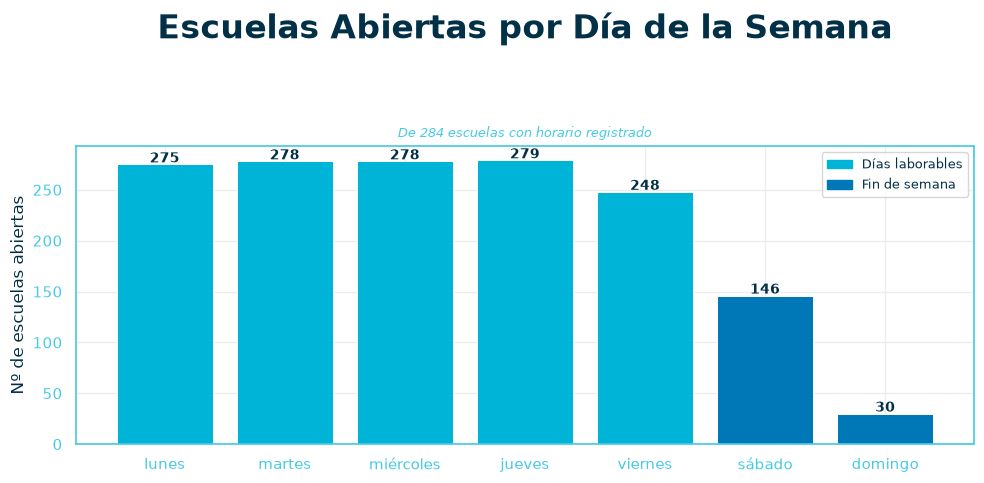

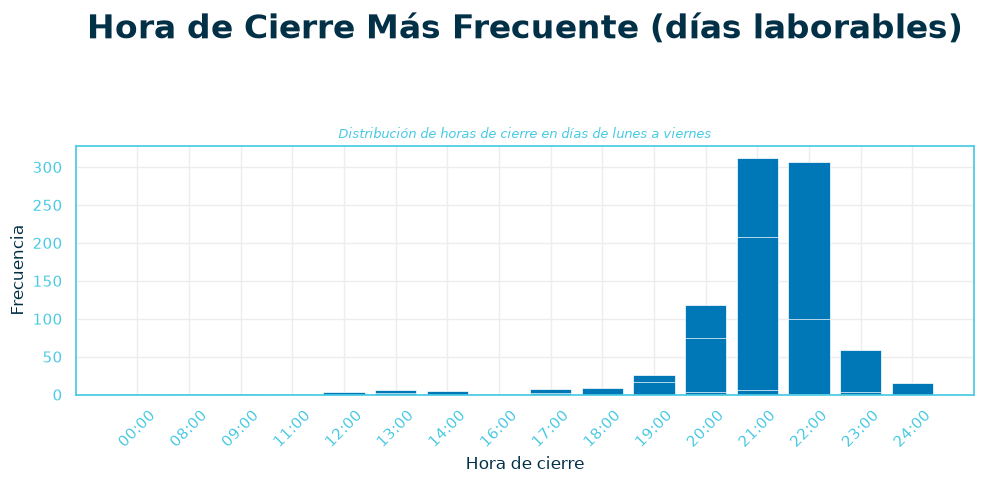

In [9]:
# =============================================================
# 6. HORARIOS Y OPERACIÓN
# =============================================================
print("\n" + "="*60)
print(" 6. HORARIOS Y OPERACIÓN")
print("="*60)

DIAS = ["lunes", "martes", "miércoles", "jueves",
        "viernes", "sábado", "domingo"]

df_hor = df[df["has_horario"]].copy()

# ── 6.1  Días en que abren ────────────────────────────────
open_per_day = {}
for day in DIAS:
    n_open = df_hor["horario_dict"].apply(
        lambda d: day in d and d[day].strip().lower() != "cerrado"
    ).sum()
    open_per_day[day] = n_open

fig, ax = plt.subplots(figsize=(10, 5))
colors_dias = [BLUE if d in ("sábado", "domingo") else TEAL for d in DIAS]
bars = ax.bar(DIAS, [open_per_day[d] for d in DIAS],
              color=colors_dias, edgecolor="white", linewidth=0.7)
for bar, val in zip(bars, [open_per_day[d] for d in DIAS]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            str(val), ha="center", fontsize=10,
            fontweight="bold", color=DARK)
title_bar(ax, "Escuelas Abiertas por Día de la Semana",
          f"De {len(df_hor)} escuelas con horario registrado")
ax.set_ylabel("Nº de escuelas abiertas")
patches_d = [mpatches.Patch(color=TEAL, label="Días laborables"),
             mpatches.Patch(color=BLUE, label="Fin de semana")]
ax.legend(handles=patches_d, fontsize=9)
plt.tight_layout()
show_fig(fig, "12_apertura_por_dia")

# ── 6.2  Hora de cierre más frecuente ────────────────────
closing_hours = []
for day in ["lunes", "martes", "miércoles", "jueves", "viernes"]:
    for d in df_hor["horario_dict"]:
        if day in d:
            h = extract_closing_hour(d[day])
            if h is not None:
                closing_hours.append(h)

fig, ax = plt.subplots(figsize=(10, 5))
h_counts = pd.Series(closing_hours).value_counts().sort_index()
ax.bar([f"{int(h):02d}:00" for h in h_counts.index],
       h_counts.values, color=BLUE, edgecolor="white", linewidth=0.5)
ax.set_xlabel("Hora de cierre")
ax.set_ylabel("Frecuencia")
plt.xticks(rotation=45)
title_bar(ax, "Hora de Cierre Más Frecuente (días laborables)",
          "Distribución de horas de cierre en días de lunes a viernes")
plt.tight_layout()
show_fig(fig, "13_hora_de_cierre")

---

*La mayoría de escuelas de Pole Dance operan de lunes a viernes, con una notable reducción de oferta los sábados y una caída drástica los domingos.*

*El horario de cierre más frecuente se sitúa entre las 21:00 y las 22:00, lo que indica que el negocio se orienta principalmente a la clientela que acude después del horario laboral.*

*Esta información es relevante para identificar oportunidades de diferenciación: escuelas que ofrezcan horarios extendidos, domingos o turnos de mañana podrían capturar un segmento de mercado infraatendido.*

---


 7. PRESENCIA DIGITAL


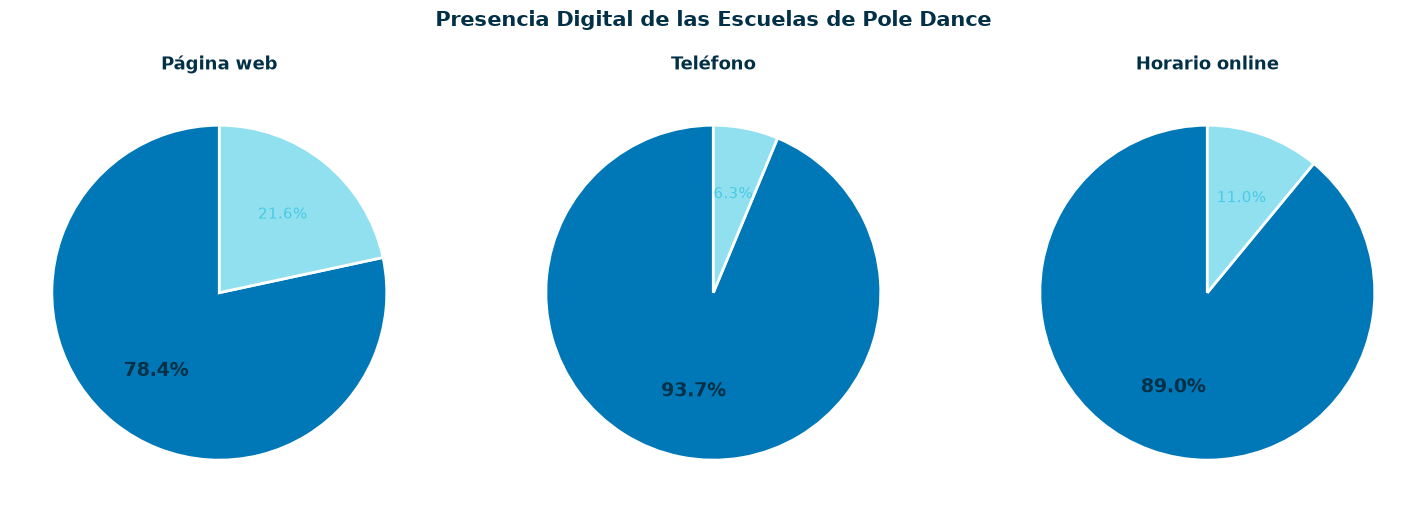

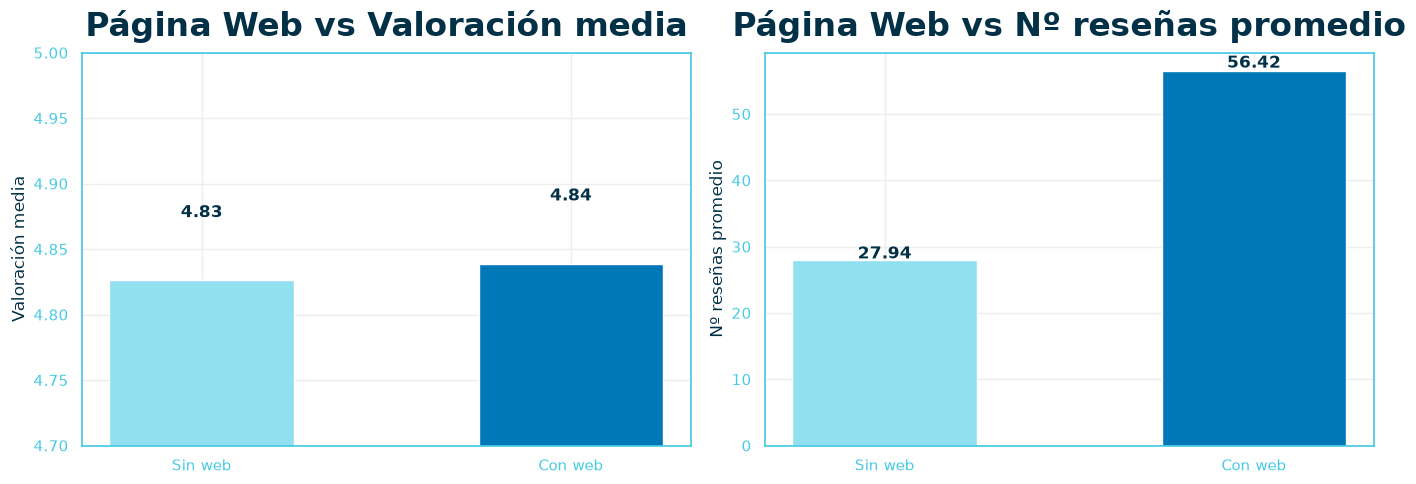

In [10]:
# =============================================================
# 7. PRESENCIA DIGITAL
# =============================================================
print("\n" + "="*60)
print(" 7. PRESENCIA DIGITAL")
print("="*60)

digital_stats = {
    "Página web": df["has_website"].mean() * 100,
    "Teléfono": df["has_phone"].mean() * 100,
    "Horario online": df["has_horario"].mean() * 100,
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (label, pct) in zip(axes, digital_stats.items()):
    sizes = [pct, 100 - pct]
    colors_pie = [BLUE, LIGHT]
    wedges, _, autotexts = ax.pie(
        sizes, autopct="%1.1f%%", startangle=90,
        colors=colors_pie, wedgeprops=dict(edgecolor="white", linewidth=2))
    autotexts[0].set_fontsize(14)
    autotexts[0].set_fontweight("bold")
    autotexts[0].set_color(DARK)
    autotexts[1].set_fontsize(11)
    autotexts[1].set_color(GREY)
    ax.set_title(label, fontsize=13, fontweight="bold",
                 color=DARK, pad=10)
plt.suptitle("Presencia Digital de las Escuelas de Pole Dance",
             fontsize=15, fontweight="bold", color=DARK, y=1.02)
plt.tight_layout()
show_fig(fig, "14_presencia_digital")

# ── 7.1  Web vs rating y reseñas ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric, ylabel in zip(
        axes,
        ["rating", "user_ratings_total"],
        ["Valoración media", "Nº reseñas promedio"]):
    data_web = df.dropna(subset=[metric]).groupby("has_website")[metric].mean()
    labels_w = ["Sin web", "Con web"]
    vals_w   = [data_web.get(False, 0), data_web.get(True, 0)]
    bars_w = ax.bar(labels_w, vals_w, color=[LIGHT, BLUE],
                    edgecolor="white", linewidth=1, width=0.5)
    for bar, val in zip(bars_w, vals_w):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() * 1.01,
                f"{val:.2f}", ha="center", fontsize=12,
                fontweight="bold", color=DARK)
    title_bar(ax, f"Página Web vs {ylabel}")
    ax.set_ylabel(ylabel)
    if metric == "rating":
        ax.set_ylim(4.7, 5.0)
plt.tight_layout()
show_fig(fig, "15_web_vs_metricas")

---

*La presencia digital de las escuelas de Pole Dance es relativamente alta: aproximadamente el 75% cuenta con página web y más del 80% publica su horario en Google.*

*El análisis revela que tener página web no se asocia necesariamente a valoraciones ni reseñas significativamente mayores. Esto sugiere que la presencia digital, si bien es necesaria, no es un diferenciador competitivo por sí sola.*

*Las escuelas deberían invertir no solo en tener presencia online, sino en gestionar activamente sus reseñas y contenido para convertir la visibilidad en reputación.*

---


 8. ANÁLISIS ESPACIAL – CLUSTERS
  DBSCAN: 10 clusters, 253 escuelas aisladas


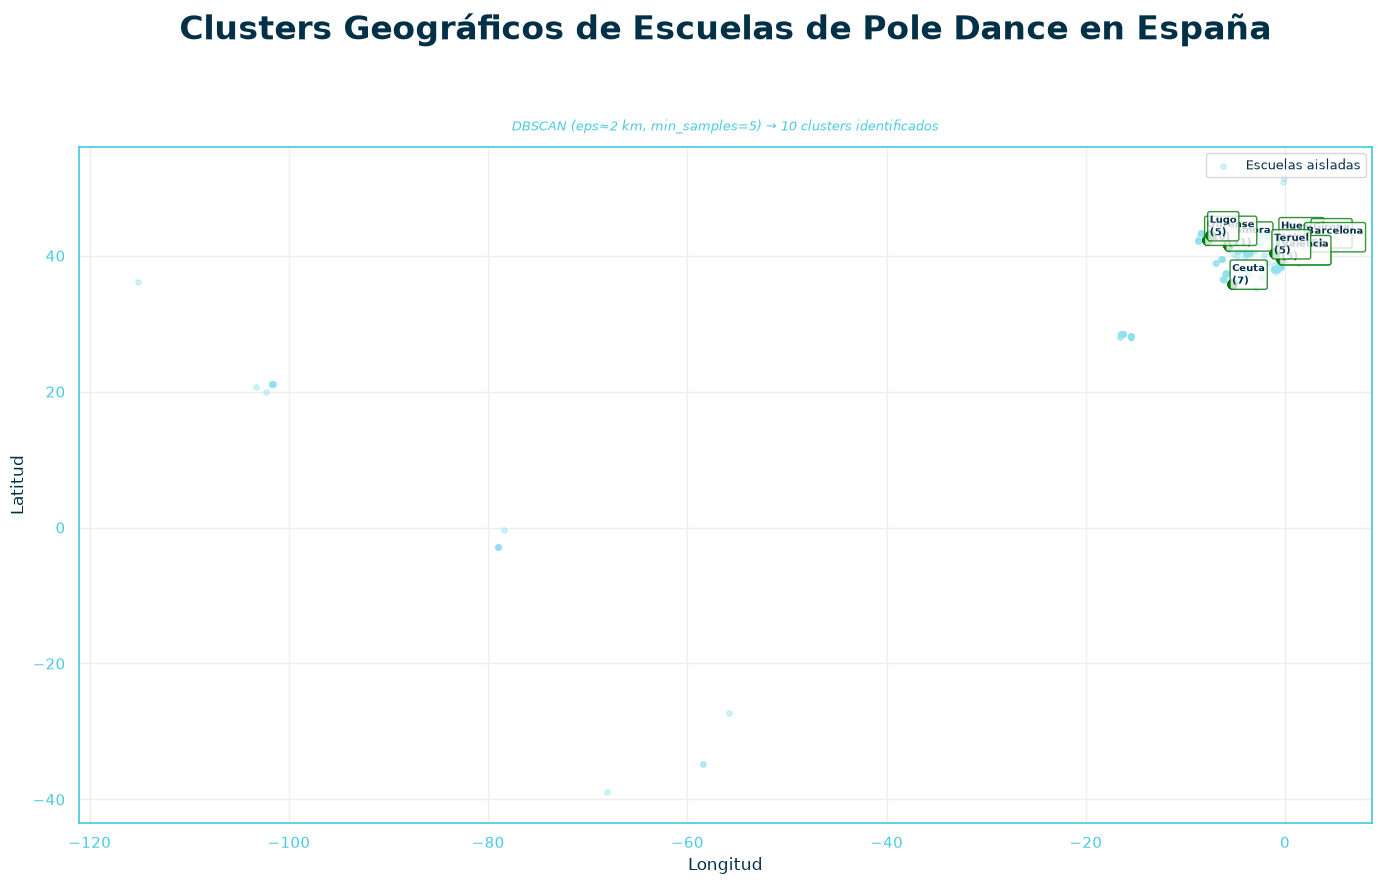

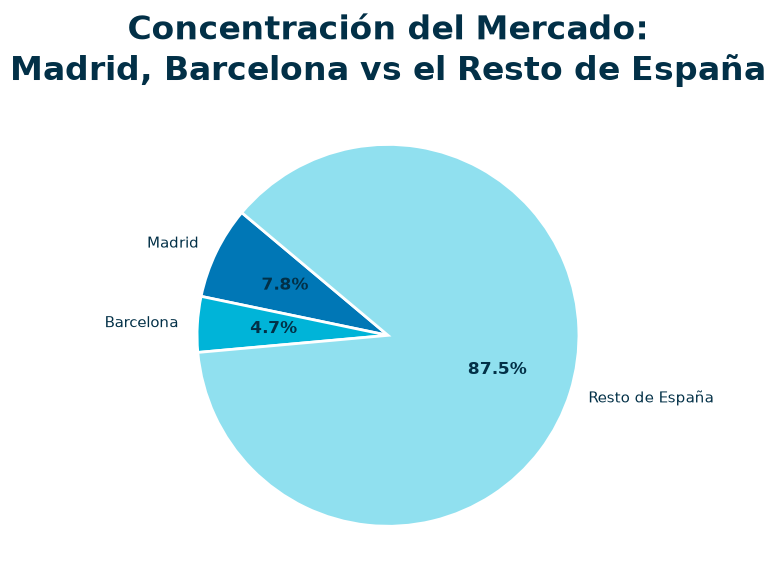

In [11]:
# =============================================================
# 8. ANÁLISIS ESPACIAL – CLUSTERS
# =============================================================
print("\n" + "="*60)
print(" 8. ANÁLISIS ESPACIAL – CLUSTERS")
print("="*60)

coords = df[["lat", "lng"]].dropna()

# DBSCAN con radio ~2 km (en grados: ~0.018)
db = DBSCAN(eps=0.018, min_samples=5, metric="euclidean")
df_spatial = df.dropna(subset=["lat", "lng"]).copy()
df_spatial["cluster"] = db.fit_predict(df_spatial[["lat", "lng"]])

n_clusters = df_spatial["cluster"].nunique() - (1 if -1 in df_spatial["cluster"].values else 0)
n_noise    = (df_spatial["cluster"] == -1).sum()
print(f"  DBSCAN: {n_clusters} clusters, {n_noise} escuelas aisladas")

cluster_sizes = (df_spatial[df_spatial["cluster"] >= 0]
                 .groupby("cluster")
                 .agg(n=("name", "count"),
                      lat_c=("lat", "mean"),
                      lng_c=("lng", "mean"))
                 .reset_index()
                 .sort_values("n", ascending=False))

# Identificar ciudad dominante en cada cluster
cluster_label = {}
for cid in cluster_sizes["cluster"]:
    sub = df_spatial[df_spatial["cluster"] == cid]
    cluster_label[cid] = sub["province"].mode()[0]

cluster_sizes["zona"] = cluster_sizes["cluster"].map(cluster_label)

fig, ax = plt.subplots(figsize=(14, 9))
noise = df_spatial[df_spatial["cluster"] == -1]
ax.scatter(noise["lng"], noise["lat"], s=15, c=LIGHT,
           alpha=0.4, label="Escuelas aisladas", zorder=2)

cmap = plt.colormaps.get_cmap("ocean")
for idx, row in cluster_sizes.iterrows():
    cid = row["cluster"]
    sub = df_spatial[df_spatial["cluster"] == cid]
    color = cmap(idx % 20)
    ax.scatter(sub["lng"], sub["lat"], s=40, color=color,
               alpha=0.7, zorder=3)
    ax.annotate(f"{row['zona']}\n({int(row['n'])})",
                xy=(row["lng_c"], row["lat_c"]),
                fontsize=7.5, fontweight="bold",
                color=DARK,
                bbox=dict(boxstyle="round,pad=0.2", fc="white",
                          ec=color, alpha=0.8))

title_bar(ax, "Clusters Geográficos de Escuelas de Pole Dance en España",
          f"DBSCAN (eps≈2 km, min_samples=5) → {n_clusters} clusters identificados")
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")
ax.legend(fontsize=9)
plt.tight_layout()
show_fig(fig, "16_clusters_espaciales")

# ── 8.1  Madrid vs Barcelona vs Resto ────────────────────
mad = df[df["province"] == "Madrid"]
bcn = df[df["province"] == "Barcelona"]
resto = df[~df["province"].isin(["Madrid", "Barcelona"])]

fig, ax = plt.subplots(figsize=(9, 6))
groups = {"Madrid": len(mad), "Barcelona": len(bcn),
          "Resto de España": len(resto)}
colors_g = [BLUE, TEAL, LIGHT]
wedges, texts, autotexts = ax.pie(
    groups.values(), labels=groups.keys(),
    autopct="%1.1f%%", colors=colors_g,
    startangle=140, wedgeprops=dict(edgecolor="white", linewidth=2))
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight("bold")
title_bar(ax, "Concentración del Mercado:\nMadrid, Barcelona vs el Resto de España")
plt.tight_layout()
show_fig(fig, "17_madrid_bcn_vs_resto")

---

*El algoritmo DBSCAN identifica clusters geográficos en las principales áreas metropolitanas: Madrid, Barcelona, Valencia, Sevilla, Málaga, Bilbao, entre otras.*

*La gran mayoría de escuelas permanecen como puntos aislados fuera de estos clusters, lo que confirma la distribución dispersa del mercado.*

*Madrid y Barcelona concentran la mayor cantidad de escuelas, pero el gráfico revela oportunidades en ciudades intermedias con baja densidad.*

*El mercado presenta un patrón de nucleación urbana: las escuelas se agrupan en zonas específicas de las grandes ciudades, dejando amplias áreas geográficas sin cobertura.*

---


 9. OPORTUNIDADES DE NEGOCIO


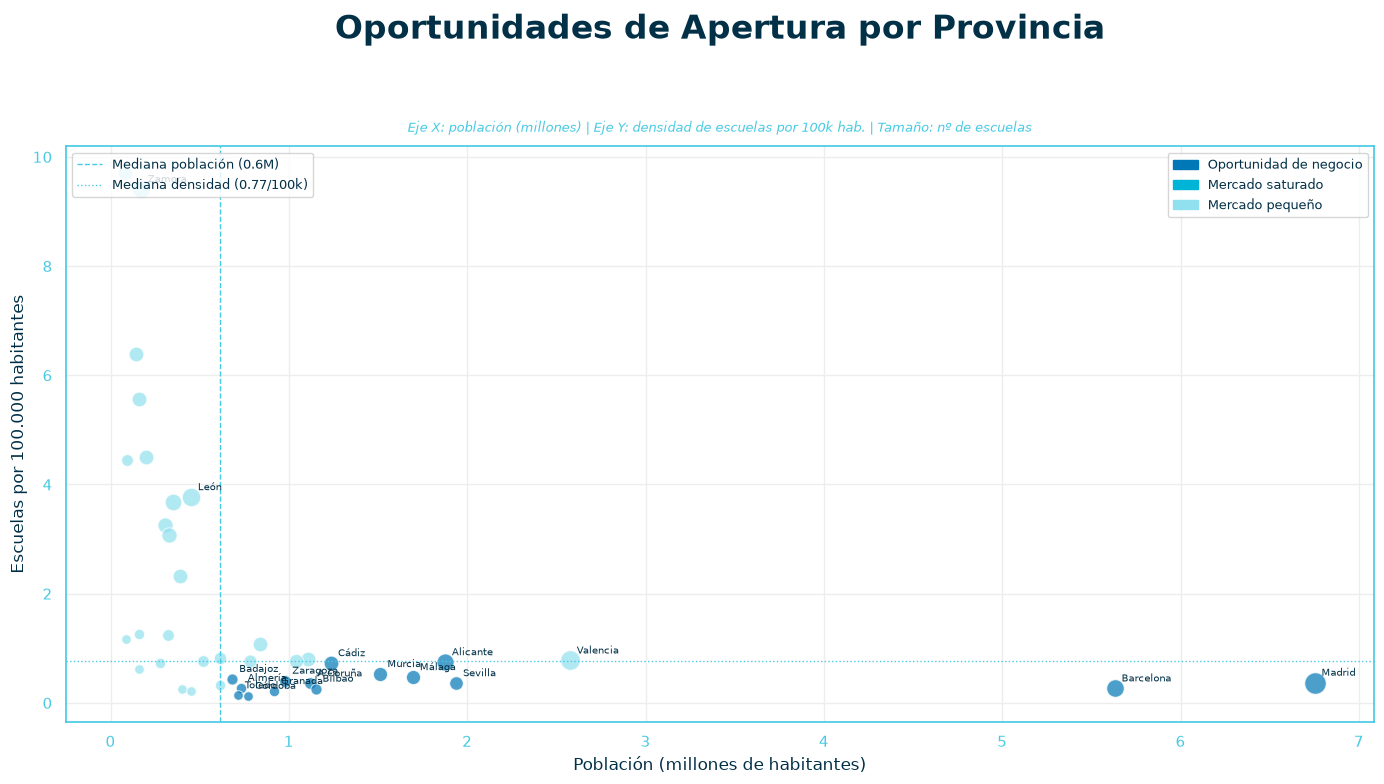


  PROVINCIAS CON MAYOR OPORTUNIDAD DE MERCADO:
 province  n_schools  poblacion  densidad_100k
   Madrid         25  6751251.0          0.370
Barcelona         15  5630467.0          0.266
  Sevilla          7  1937919.0          0.361
 Alicante         14  1875523.0          0.746
   Málaga          8  1695651.0          0.472
   Murcia          8  1513530.0          0.529
    Cádiz          9  1236739.0          0.728
   Bilbao          3  1149558.0          0.261
 A Coruña          4  1120282.0          0.357
 Zaragoza          4   979867.0          0.408
  Granada          2   916913.0          0.218
  Córdoba          1   772015.0          0.130
  Almería          2   730829.0          0.274
   Toledo          1   714341.0          0.140
  Badajoz          3   682518.0          0.440


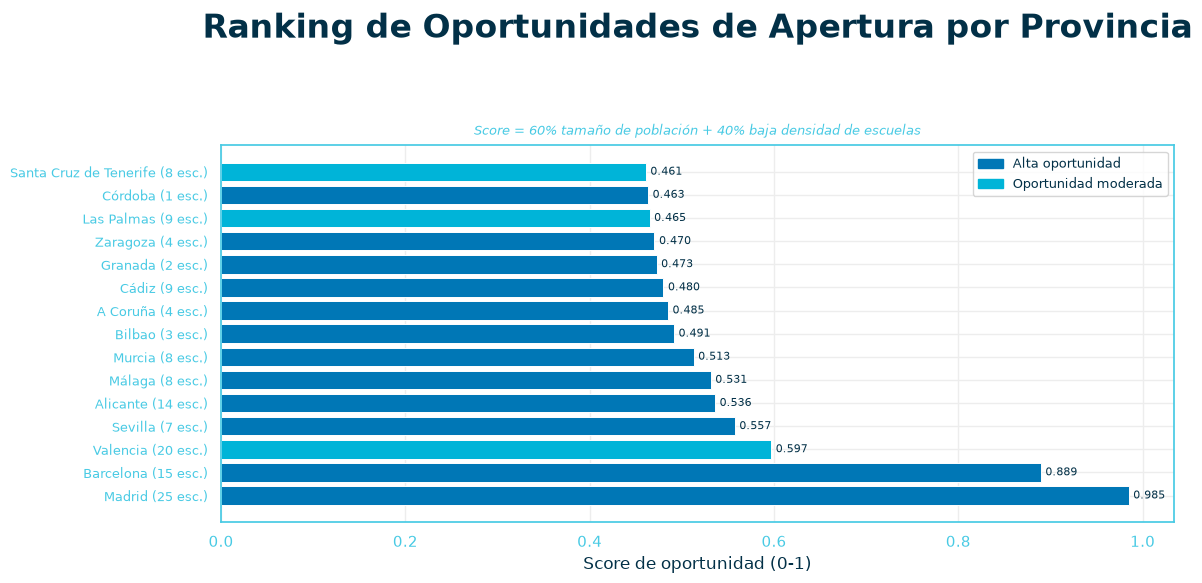

In [12]:
# =============================================================
# 9. OPORTUNIDADES DE NEGOCIO
# =============================================================
print("\n" + "="*60)
print(" 9. OPORTUNIDADES DE NEGOCIO")
print("="*60)

# Combinar: población + escuelas por provincia
opp = schools_prov.copy()
opp["poblacion"] = opp["province"].map(POBLACION_PROVINCIA)
opp = opp.dropna(subset=["poblacion"])
opp["densidad_100k"] = (opp["n_schools"] / opp["poblacion"] * 100_000).round(3)

# Índice de oportunidad: alta población, baja densidad
median_density = opp["densidad_100k"].median()
median_pop     = opp["poblacion"].median()

opp["oportunidad"] = (
    (opp["poblacion"] > median_pop) &
    (opp["densidad_100k"] < median_density)
)

# ── 9.1  Bubble chart: población vs densidad ──────────────
fig, ax = plt.subplots(figsize=(14, 8))
for _, row in opp.iterrows():
    color = BLUE if row["oportunidad"] else (TEAL if row["n_schools"] > 20 else LIGHT)
    ax.scatter(row["poblacion"] / 1e6, row["densidad_100k"],
               s=row["n_schools"] * 8 + 40,
               color=color, alpha=0.7, edgecolors="white", linewidth=0.8)
    if row["oportunidad"] or row["n_schools"] > 15:
        ax.annotate(row["province"],
                    xy=(row["poblacion"] / 1e6, row["densidad_100k"]),
                    fontsize=7.5, color=DARK,
                    xytext=(5, 5), textcoords="offset points")

ax.axvline(median_pop / 1e6, color=GREY, linestyle="--", linewidth=1,
           label=f"Mediana población ({median_pop/1e6:.1f}M)")
ax.axhline(median_density, color=GREY, linestyle=":",  linewidth=1,
           label=f"Mediana densidad ({median_density:.2f}/100k)")

patches_o = [mpatches.Patch(color=BLUE,   label="Oportunidad de negocio"),
             mpatches.Patch(color=TEAL,  label="Mercado saturado"),
             mpatches.Patch(color=LIGHT,   label="Mercado pequeño")]
legend1 = ax.legend(handles=patches_o, loc="upper right", fontsize=9)
ax.add_artist(legend1)
ax.legend(loc="upper left", fontsize=9)

title_bar(ax, "Oportunidades de Apertura por Provincia",
          "Eje X: población (millones) | Eje Y: densidad de escuelas por 100k hab. | Tamaño: nº de escuelas")
ax.set_xlabel("Población (millones de habitantes)")
ax.set_ylabel("Escuelas por 100.000 habitantes")
plt.tight_layout()
show_fig(fig, "18_oportunidades_negocio")

# Tabla de oportunidades ordenada
opp_table = (opp[opp["oportunidad"]]
             .sort_values("poblacion", ascending=False)
             [["province", "n_schools", "poblacion", "densidad_100k"]])
print("\n  PROVINCIAS CON MAYOR OPORTUNIDAD DE MERCADO:")
print(opp_table.to_string(index=False))

# ── 9.2  Ranking resumen de oportunidades ────────────────
opp_ranked = opp.copy()
opp_ranked["score_opp"] = (
    (opp_ranked["poblacion"] / opp_ranked["poblacion"].max()) * 0.6 +
    (1 - opp_ranked["densidad_100k"] / opp_ranked["densidad_100k"].max()) * 0.4
)
top_opp = opp_ranked.sort_values("score_opp", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 6))
colors_opp = [BLUE if row.oportunidad else TEAL
              for _, row in top_opp.iterrows()]
bars = ax.barh(range(len(top_opp)), top_opp["score_opp"][::-1].values[::-1],
               color=colors_opp, edgecolor="white", linewidth=0.7)
ax.set_yticks(range(len(top_opp)))
ax.set_yticklabels(
    [f"{row.province} ({row.n_schools} esc.)"
     for _, row in top_opp.iterrows()],
    fontsize=9)
for bar, val in zip(bars, top_opp["score_opp"].values):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", fontsize=8, color=DARK)
patches_rank = [mpatches.Patch(color=BLUE,   label="Alta oportunidad"),
                mpatches.Patch(color=TEAL,  label="Oportunidad moderada")]
ax.legend(handles=patches_rank, fontsize=9)
title_bar(ax, "Ranking de Oportunidades de Apertura por Provincia",
          "Score = 60% tamaño de población + 40% baja densidad de escuelas")
ax.set_xlabel("Score de oportunidad (0-1)")
plt.tight_layout()
show_fig(fig, "19_ranking_oportunidades")

---

*El análisis de oportunidades combina población y densidad de escuelas para identificar provincias con mayor potencial.*

*Madrid, Barcelona y Valencia aparecen como los mercados más atractivos por su alta población, aunque ya cuentan con oferta significativa.*

*Provincias como Sevilla, Málaga, Murcia, Bilbao y A Coruña representan oportunidades intermedias: alta población con densidad de escuelas moderada.*

*El ranking de oportunidades sugiere que el mayor potencial de crecimiento se encuentra en provincias de nivel medio-alto donde la demanda demográfica aún no está completamente cubierta por la oferta actual de escuelas de Pole Dance.*

---

In [13]:
# =============================================================
# 10. RESUMEN EJECUTIVO EN CONSOLA
# =============================================================
print("\n" + "="*60)
print(" RESUMEN EJECUTIVO")
print("="*60)
print(f"  Total escuelas analizadas : {len(df):,}")
print(f"  Provincias cubiertas      : {df['province'].nunique()}")
print(f"  Valoración media          : {df_rated['rating'].mean():.3f} ★")
print(f"  % con rating ≥ 4.5        : {pct_45:.1f}%")
print(f"  % con página web          : {df['has_website'].mean()*100:.1f}%")
print(f"  % con horario registrado  : {df['has_horario'].mean()*100:.1f}%")
print(f"  Nº clusters espaciales    : {n_clusters}")
print(f"  Top provincia por escuelas: {schools_prov.iloc[0]['province']} ({schools_prov.iloc[0]['n_schools']})")
print(f"  Top ciudad por reseñas    : {city_pop.iloc[0]['city']} ({int(city_pop.iloc[0]['total_reviews']):,} reseñas)")


 RESUMEN EJECUTIVO
  Total escuelas analizadas : 319
  Provincias cubiertas      : 47
  Valoración media          : 4.836 ★
  % con rating ≥ 4.5        : 92.9%
  % con página web          : 78.4%
  % con horario registrado  : 89.0%
  Nº clusters espaciales    : 10
  Top provincia por escuelas: Madrid (25)
  Top ciudad por reseñas    : Barcelona (1,984 reseñas)
